# Fine branch biomass estimation: structural cross-section model (Fournier et al. 2024, *Annals of Botany*)

Reproduction of **one minimal analysis** from:
> *Advancing fine branch biomass estimation with lidar and structural models*, Ann Bot 134(3):455–466, 2024. DOI [10.1093/aob/mcae083](https://doi.org/10.1093/aob/mcae083), PMCID PMC11341666.

**Scope.** Fit the paper's six-variable structural model that predicts segment cross-sectional area (CSA, mm²) from lidar-derivable structural traits, and evaluate it with the authors' 10-fold cross-validation. This is the segment-scale part of the paper's Table 2; **branch-scale biomass, tree-scale application, lidar/PlantScan3D reconstruction and wood-density volume/biomass are out of scope.**

**Method fidelity.** The analysis runs the **authors' own Julia implementation** (pinned commit `f119165356b4ae9020bb3e079a0ccb6ff294214c` of [VEZY/Biomass_evaluation_LiDAR](https://github.com/VEZY/Biomass_evaluation_LiDAR), notebook `1-code/4-model_cross_section.jl`): the model formula, data filters, and error-metric functions are copied verbatim. The Colab orchestration (Julia install, data fetch, plotting) is AI-assisted.

**AI-assisted adaptation notice / AI支援のお知らせ:** **This notebook is an AI-assisted adaptation of the authors' Julia Pluto notebook into plain Julia scripts driven from Python. The authors did not provide this Colab implementation. The executed example and listed checks were validated, but untested behavior is not guaranteed. / 本ノートブックは著者のJuliaノートブックをAIがColab向けに再構成したものです。著者自身によるColab実装ではない点にご注意ください。**

**Data.** Zenodo record [10.5281/zenodo.7038482](https://doi.org/10.5281/zenodo.7038482) v1.0.0 (CC-BY-4.0), file `Biomass_evaluation_LiDAR.zip` (3.94 GB). Only the small precomputed segment tables in `0-data/1.2-mtg_manual_measurement_corrected_enriched/` are required; this notebook downloads **only those members** via HTTP range requests (with a documented full-archive fallback). All data stays on the Colab VM.

**Runtime.** CPU only (a linear model on ~10³–10⁴ rows; no GPU is used anywhere in the method). Expected total time ≈ 10–15 min; downloads ≈ 250 MB (Julia + partial archive) or 3.94 GB on the fallback route.


## 1. Runtime check

**Expected result:** Python 3 with ≥2 CPU cores and no GPU requirement. This reproduction never needs a GPU; select the plain CPU runtime if Colab asks. / GPUは不要です。CPU ランタイムを選択してください。


In [ ]:
import os, sys, platform, urllib.request
print("python:", sys.version.split()[0])
print("machine:", platform.machine())
print("cpus:", os.cpu_count())
print("gpu present:", __import__("shutil").which("nvidia-smi") is not None)

python: 3.13.15
machine: x86_64
cpus: 2
gpu present: False


## 2. Install Julia 1.10

**Purpose:** the authors' analysis is Julia 1.10 code (their `Manifest.toml` pins `julia_version = "1.10.2"`). We install the official Julia 1.10.x binary from julialang.org into `/content` — no compiler build needed.

**Expected result:** `julia -version` prints `julia version 1.10.x`. (~1–2 min, ~170 MB download.) / 著者と同じ Julia 1.10 系を公式バイナリで導入します。


In [ ]:
import subprocess, urllib.request, tarfile, pathlib

JULIA_VER = "1.10.9"
TARBALL = f"julia-{JULIA_VER}-linux-x86_64.tar.gz"
URL = f"https://julialang-s3.julialang.org/bin/linux/x64/1.10/{TARBALL}"
dest = pathlib.Path("/content"); tar_path = dest / TARBALL

if not (dest / f"julia-{JULIA_VER}").exists():
    print("downloading", URL)
    urllib.request.urlretrieve(URL, tar_path)
    with tarfile.open(tar_path) as tf:
        tf.extractall(dest)
    tar_path.unlink()

JULIA = str(dest / f"julia-{JULIA_VER}" / "bin" / "julia")
print(subprocess.run([JULIA, "--version"], capture_output=True, text=True).stdout.strip())

downloading https://julialang-s3.julialang.org/bin/linux/x64/1.10/julia-1.10.9-linux-x86_64.tar.gz


/tmp/ipykernel_1150/1535815935.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(dest)


julia version 1.10.9


## 3. Install the Julia packages used by the model path

**Purpose:** the authors' `Project.toml` lists 18 packages (Makie, Pluto, ...), but the segment-scale model path only needs `CSV`, `DataFrames`, `GLM`, `MLBase`, `StatsBase` plus stdlib `Statistics`/`Random`. We install exactly that subset — the scientific operations and formula are unchanged.

**Expected result:** package precompilation finishes without error (~3–5 min). / モデル計算に必要なパッケージのみ導入します（Makie/Ploto等の描画・ノートブック環境は不要）。


In [ ]:
import subprocess
pkgs = ["CSV", "DataFrames", "GLM", "MLBase", "StatsBase"]
script = "using Pkg; Pkg.add([" + ", ".join(f'"{p}"' for p in pkgs) + "])"
r = subprocess.run([JULIA, "-e", script])
r.check_returncode()

## 4. Get the authors' data from Zenodo (Colab only)

**Purpose:** the GitHub repository contains only code — all measurements live in the Zenodo archive `Biomass_evaluation_LiDAR.zip` (record 7038482, v1.0.0). We list the zip's central directory over HTTP and download **only** the precomputed segment tables (`0-data/1.2-mtg_manual_measurement_corrected_enriched/*.csv`) using HTTP range requests (`remotezip`). If ranged access fails, we fall back to downloading the full 3.94 GB archive and extracting the same members. Nothing is written to the host; everything stays under `/content`.

**Expected result:** the six branch CSVs (`tree11h` … `tree13l.csv`, ~130 KB each) under `/content/data/1.2-mtg_manual_measurement_corrected_enriched/`. / Zenodo アーカイブから必要なセグメント表 CSV のみを取得します（失敗時はアーカイブ全体をダウンロード）。


In [ ]:
import subprocess, zipfile, pathlib, shutil

ZENODO_URL = ("https://zenodo.org/api/records/7038482/files/"
              "Biomass_evaluation_LiDAR.zip/content")
ZIP_PREFIX = "Biomass_evaluation_LiDAR/0-data/1.2-mtg_manual_measurement_corrected_enriched/"
DATA_DIR = pathlib.Path("/content/data/1.2-mtg_manual_measurement_corrected_enriched")

def needed_members(names):
    return sorted(n for n in names if n.startswith(ZIP_PREFIX) and n.endswith(".csv"))

def fetch_remotezip():
    subprocess.run(["pip", "install", "-q", "remotezip"], check=True)
    from remotezip import RemoteZip
    with RemoteZip(ZENODO_URL) as z:
        members = needed_members(z.namelist())
        print("zip members needed:", members)
        assert members, "no matching members in archive"
        for m in members:
            z.extract(m, "/content/data")
    return members

def fetch_full():
    zip_path = pathlib.Path("/content/Biomass_evaluation_LiDAR.zip")
    if not zip_path.exists():
        print("fallback: downloading full 3.94 GB archive ...")
        with urllib.request.urlopen(ZENODO_URL) as r, open(zip_path, "wb") as f:
            shutil.copyfileobj(r, f, length=1 << 24)
    with zipfile.ZipFile(zip_path) as z:
        members = needed_members(z.namelist())
        print("zip members needed:", members)
        assert members, "no matching members in archive"
        z.extractall("/content/data", members=members)
    return members

try:
    members = fetch_remotezip()
except Exception as e:
    print("remotezip route failed:", repr(e))
    members = fetch_full()

DATA_DIR.mkdir(parents=True, exist_ok=True)
for m in members:
    src = pathlib.Path("/content/data") / m
    dst = DATA_DIR / pathlib.Path(m).name
    shutil.copyfile(src, dst)
    print(f"{dst}  {dst.stat().st_size} bytes")

zip members needed: ['Biomass_evaluation_LiDAR/0-data/1.2-mtg_manual_measurement_corrected_enriched/tree11h.csv', 'Biomass_evaluation_LiDAR/0-data/1.2-mtg_manual_measurement_corrected_enriched/tree11l.csv', 'Biomass_evaluation_LiDAR/0-data/1.2-mtg_manual_measurement_corrected_enriched/tree12h.csv', 'Biomass_evaluation_LiDAR/0-data/1.2-mtg_manual_measurement_corrected_enriched/tree12l.csv', 'Biomass_evaluation_LiDAR/0-data/1.2-mtg_manual_measurement_corrected_enriched/tree13h.csv', 'Biomass_evaluation_LiDAR/0-data/1.2-mtg_manual_measurement_corrected_enriched/tree13l.csv']


/content/data/1.2-mtg_manual_measurement_corrected_enriched/tree11h.csv  130716 bytes
/content/data/1.2-mtg_manual_measurement_corrected_enriched/tree11l.csv  208822 bytes
/content/data/1.2-mtg_manual_measurement_corrected_enriched/tree12h.csv  158561 bytes
/content/data/1.2-mtg_manual_measurement_corrected_enriched/tree12l.csv  139958 bytes
/content/data/1.2-mtg_manual_measurement_corrected_enriched/tree13h.csv  118024 bytes
/content/data/1.2-mtg_manual_measurement_corrected_enriched/tree13l.csv  115566 bytes


## 5. Verify the downloaded tables

**Purpose:** confirm the CSVs contain the columns the model needs before any fitting: the observation `cross_section` (mm², from manual diameters) and the six explanatory variables, including the pipe-model baseline `cross_section_pipe`.

**Expected result:** one row per branch segment with the model columns present. / モデルに必要な列が揃っていることを確認します。


In [ ]:
import pandas as pd, glob

files = sorted(glob.glob("/content/data/1.2-mtg_manual_measurement_corrected_enriched/*.csv"))
print(len(files), "files:", [f.split("/")[-1] for f in files])
frames = [pd.read_csv(f, low_memory=False) for f in files]
raw = pd.concat(frames, ignore_index=True)
print("total rows:", len(raw))
print("columns:", list(raw.columns))
need = ["cross_section", "cross_section_pipe", "pathlength_subtree",
        "branching_order", "segment_index_on_axis", "number_leaves",
        "segment_subtree", "symbol", "comment"]
missing = [c for c in need if c not in raw.columns]
assert not missing, f"missing columns: {missing}"
raw[need[:7]].describe()

6 files: ['tree11h.csv', 'tree11l.csv', 'tree12h.csv', 'tree12l.csv', 'tree13h.csv', 'tree13l.csv']
total rows: 5287
columns: ['id', 'symbol', 'scale', 'index', 'parent_id', 'link', 'density', 'length', 'diameter', 'axis_length', 'branching_order', 'segment_index_on_axis', 'mass_g', 'volume', 'volume_subtree', 'cross_section', 'cross_section_children', 'cross_section_leaves', 'n_segments_axis', 'number_leaves', 'pathlength_subtree', 'segment_subtree', 'cross_section_pipe', 'cross_section_pipe_50', 'nleaf_proportion_siblings', 'nleaves_siblings', 'cross_section_all', 'comment', 'id_cor']


,cross_section,cross_section_pipe,pathlength_subtree,branching_order,segment_index_on_axis,number_leaves,segment_subtree
count,3515.000000,5287.000000,3511.000000,5287.000000,3518.000000,3518.000000,3518.000000
mean,148.799707,100.553274,2506.624027,2.094572,4.322058,13.169983,24.869812
std,427.884565,419.730833,8812.464936,1.126565,7.609762,43.246641,86.183771
min,3.976078,1.919098,1.000000,1.000000,1.000000,1.000000,1.000000
25%,23.758294,10.142299,85.000000,1.000000,1.000000,1.000000,2.000000
50%,37.230406,15.593329,215.000000,2.000000,1.000000,1.500000,2.000000
75%,75.429640,28.953129,723.500000,3.000000,4.000000,5.000000,7.000000
max,5089.576448,5089.576448,87906.800000,8.000000,63.000000,421.000000,844.000000


## 6. The authors' Julia analysis code

**Purpose:** write two Julia files that reproduce the pinned notebook `4-model_cross_section.jl` exactly for this path:

- `funcs.jl` — the authors' metric functions `RMSE`, `nRMSE`, `EF`, `Bias`, `nBias` and `bind_csv_files`, copied **verbatim** from the pinned notebook (cells 33–39).
- `model.jl` — the authors' data construction (cell 40) and model formula (cell 14), then 10-fold cross-validation (cell 41: `MLBase.cross_validate`, `Kfold(n,10)`, `Random.seed!(1234)`) and the whole-data fit (cell 42) with a Table-2-style SM/PMT statistic summary (cell 47).

The only changes are the data directory (Colab paths) and printing instead of Pluto display. / 著者のコードを逐語コピーし、パスと出力だけColab向けに調整します。


In [ ]:
funcs_jl = r'''
# ---- Verbatim from VEZY/Biomass_evaluation_LiDAR @ f119165, 4-model_cross_section.jl ----
function RMSE(obs, sim; digits=2)
    return round(sqrt(sum((obs .- sim) .^ 2) / length(obs)), digits=digits)
end

function nRMSE(obs, sim; digits=4)
    return round(sqrt(sum((obs .- sim) .^ 2) / length(obs)) / (findmax(obs)[1] - findmin(obs)[1]), digits=digits)
end

function EF(obs, sim, digits=4)
    SSres = sum((obs - sim) .^ 2)
    SStot = sum((obs .- mean(obs)) .^ 2)
    return round(1 - SSres / SStot, digits=digits)
end

function Bias(obs, sim; digits=2)
    return round(mean(sim .- obs), digits=digits)
end

function nBias(obs, sim; digits=2)
    return round(mean((sim .- obs)) / (findmax(obs)[1] - findmin(obs)[1]), digits=digits)
end

function bind_csv_files(csv_files)
    dfs = []
    for i in csv_files
        df_i = CSV.read(i, DataFrame)
        df_i[:, :branch] .= splitext(basename(i))[1]

        transform!(
            df_i,
            :branch => ByRow(x -> x[5:end-1]) => :tree
        )

        rename!(
            df_i,
            :branch => :unique_branch
        )

        transform!(
            df_i,
            :unique_branch => ByRow(x -> x[end]) => :branch
        )
        push!(dfs, df_i)
    end

    df = dfs[1]
    for i in 2:length(dfs)
        df = vcat(df, dfs[i])
    end

    return df
end
'''
with open("/content/funcs.jl", "w") as f:
    f.write(funcs_jl)
print("funcs.jl written")

funcs.jl written


### Model script: data filters, formula, 10-fold CV, whole-data fit

The data construction and formula below are the authors' cells 40, 14, 41 and 42 verbatim (paths adapted); broken/aborted segments (`comment` ∈ casse/CASSE/AVORTE/...) are removed, only segments (`symbol == "S"`) of trees 11–13 are kept. Cross-validation predicts held-out folds with the same formula and scores them with the authors' `nRMSE`.


In [ ]:
model_jl = r'''
include("/content/funcs.jl")
using CSV, DataFrames, GLM, Statistics, Random, MLBase, StatsBase

csv_files = filter(x -> endswith(x, ".csv"),
                   readdir("/content/data/1.2-mtg_manual_measurement_corrected_enriched", join=true))
# ---- Authors' cell 40 (verbatim) ----
df = let
    x = dropmissing(bind_csv_files(csv_files), :cross_section)
    filter!(x -> ismissing(x.comment) || !(x.comment in ["casse", "CASSE", "AVORTE", "Portait aussi un axe peut-être cassé lors de la manip"]), x)
    filter!(x -> x.symbol == "S", x)
    filter!(x -> in(x.tree, ["11", "12", "13"]), x) # Remove 2020 trees
    x
end
println("n = ", size(df, 1), " segments")

# ---- Authors' cell 14 (verbatim) ----
formula_all = @formula(cross_section ~ 0 + cross_section_pipe + pathlength_subtree +
                       branching_order + segment_index_on_axis + number_leaves + segment_subtree)

# ---- Authors' cell 41 (verbatim) ----
function compute_rmse(mod, df_ref)
    x = deepcopy(df_ref)
    x[!, "Topo. mod."] = predict(mod, x)
    x = dropmissing(x, ["Topo. mod.", "cross_section"])
    nRMSE(x[:, "Topo. mod."], x[:, :cross_section])
end

const n = size(df, 1)
Random.seed!(1234)
scores = cross_validate(
    inds -> lm(formula_all, df[inds, :]),
    (mod, inds) -> compute_rmse(mod, df[inds, :]),
    n,
    Kfold(n, 10)
)
(m, s) = round.(mean_and_std(scores), digits=4)
cv_line = "nRMSE: $m ± sd $s"
println(cv_line)
open("/content/cv_result.txt", "w") do f; write(f, cv_line); end

# ---- Authors' cell 42: whole-data fit ----
model = lm(formula_all, df)
println("coefficients (structural model, mm² units):")
show(coeftable(model))

# ---- Authors' cells 43+47: SM vs PMT statistics on the whole data ----
df_pred = deepcopy(df)
df_pred[!, "Topo. mod."] = predict(model, df_pred)
df_pred[!, "Pipe mod."] = df_pred[:, :cross_section_pipe]
rows = []
for (col, label) in [("Topo. mod.", "SM"), ("Pipe mod.", "PMT")]
    x = dropmissing(df_pred, [col, "cross_section"])
    push!(rows, (Model=label, RMSE=RMSE(x[:, "cross_section"], x[:, col]),
                 nRMSE=nRMSE(x[:, "cross_section"], x[:, col]),
                 EF=EF(x[:, "cross_section"], x[:, col]),
                 Bias=Bias(x[:, "cross_section"], x[:, col]),
                 nBias=nBias(x[:, "cross_section"], x[:, col])))
end
stats = DataFrame(rows)
println(); println(stats)
CSV.write("/content/stats_table2.csv", stats)
CSV.write("/content/segment_predictions.csv",
          select(df_pred, Cols(:tree, :branch, :id, :cross_section, "Topo. mod.", "Pipe mod.")))
'''
with open("/content/model.jl", "w") as f:
    f.write(model_jl)
print("model.jl written")

model.jl written


### Run the cross-validation and fit

**Expected result:** ~2000–6000 segments retained; 10-fold CV `nRMSE ≈ 0.016 ± …` (the paper reports **1.6%** segment-scale nRMSE for the structural model, Table 2), coefficients close to the paper's Table 1 signs (positive pipe-model and subtree-pathlength terms), and whole-data SM statistics with EF ≈ 1. / 10-fold CV の nRMSE が論文の 1.6% 前後になれば再現成功です。


In [ ]:
import subprocess
r = subprocess.run([JULIA, "/content/model.jl"], text=True,
                   stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
print(r.stdout)
r.check_returncode()

n = 3462 segments
nRMSE: 0.0158 ± sd 0.0043
coefficients (structural model, mm² units):
CoefTable(Any[[0.5205078234481753, 0.015336450391341414, 6.383944218593834, 10.938861282919554, -10.136968348437945, 4.468431169988465], [0.015156017457016691, 0.000718347595295416, 1.275846330635328, 0.4104544350827713, 2.126347603883252, 1.0544712425739111], [34.343311158380786, 21.34962306797226, 5.003693677917188, 26.650610513475506, -4.7673147748398526, 4.237603634482483], [1.2147420357284546e-222, 4.240585152138336e-95, 5.904863433895234e-7, 1.7961266627105297e-142, 1.944017921267562e-6, 2.3182152025647367e-5], [0.49079216507790546, 0.013928021574639248, 3.882455037702881, 10.134103449664686, -14.305993565823378, 2.4009812416371643], [0.550223481818445, 0.01674487920804358, 8.885433399484787, 11.743619116174422, -5.96794313105251, 6.5358810983397655]], ["Coef.", "Std. Error", "t", "Pr(>|t|)", "Lower 95%", "Upper 95%"], ["cross_section_pipe", "pathlength_subtree", "branching_order", "segment_in

### Table 2 analogue (segment scale): structural model (SM) vs pipe model (PMT)

**Purpose:** show the whole-data accuracy statistics computed with the authors' metric functions, mirroring the paper's Table 2 segment-scale rows (paper values: SM nRMSE ≈ 1.6%, PMT nRMSE ≈ 2.5%; EF close to 1 for both).

**Expected result:** a small table; SM should beat PMT with lower bias.


In [ ]:
import pandas as pd
stats = pd.read_csv("/content/stats_table2.csv")
stats

,Model,RMSE,nRMSE,EF,Bias,nBias
0,SM,57.73,0.0114,0.9799,-2.89,-0.0
1,PMT,103.35,0.0203,0.9356,-17.96,-0.0


### Measured vs predicted CSA (Figure 1 analogue)

**Purpose:** redraw the paper's Fig. 1-style scatter (measured CSA on both axes, one panel per model) from our actual predictions. This graph is created for this notebook, not an author figure. Log-log axes as in the paper.

**Expected result:** points tightly along the 1:1 line for SM; PMT slightly more scattered with a visible bias.


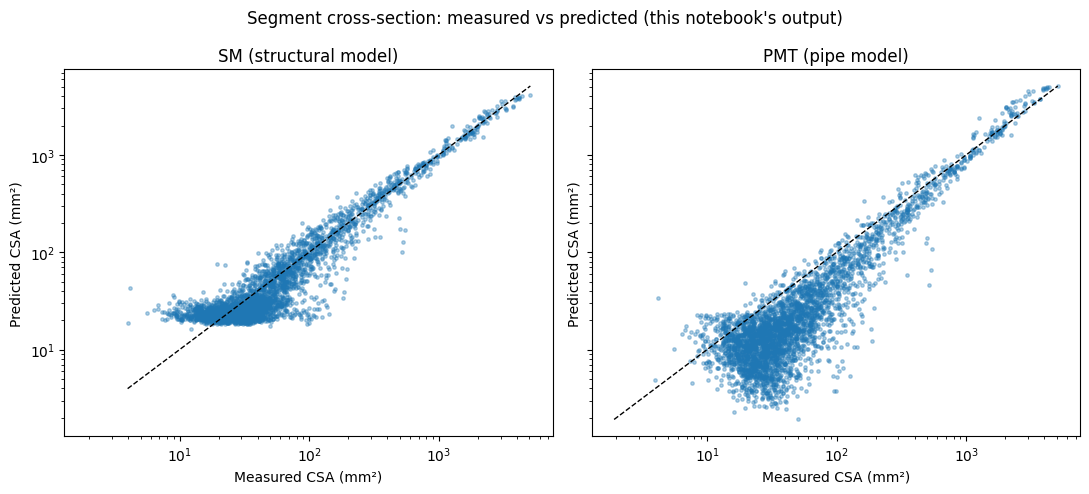

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

pred = pd.read_csv("/content/segment_predictions.csv")
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, col, title in [(axes[0], "Topo. mod.", "SM (structural model)"),
                       (axes[1], "Pipe mod.", "PMT (pipe model)")]:
    x = pred["cross_section"]; y = pred[col].astype(float)
    ax.scatter(x, y, s=6, alpha=0.35)
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Measured CSA (mm²)"); ax.set_ylabel("Predicted CSA (mm²)")
    ax.set_title(title)
fig.suptitle("Segment cross-section: measured vs predicted (this notebook's output)")
fig.tight_layout()
fig.savefig("/content/fig1_analogue.png", dpi=150)
plt.show()

### Export the results

**Purpose:** persist a small CSV with per-segment measured/predicted CSA (tree, branch, segment id) so the numbers can be inspected or downloaded.

**Expected result:** a preview of the exported table.


In [ ]:
out = pred.rename(columns={"Topo. mod.": "SM_predicted_cross_section_mm2",
                           "Pipe mod.": "PMT_pipe_model_cross_section_mm2"})
out.to_csv("/content/segment_predictions_export.csv", index=False)
out.head()

,tree,branch,id,cross_section,SM_predicted_cross_section_mm2,PMT_pipe_model_cross_section_mm2
0,11,h,3,1998.997369,1966.760644,1998.997369
1,11,h,5,168.794318,137.274783,90.180332
2,11,h,7,50.895764,84.363235,41.621692
3,11,h,9,23.328289,25.533187,11.891912
4,11,h,10,46.566257,60.383010,29.729780


## Interpretation

- The 10-fold cross-validated nRMSE printed above should match the paper's segment-scale value of **≈1.6%** (Table 2) up to fold-assignment randomness — the seed (`1234`) and fold plan (`Kfold(n,10)`) are the authors'.
- The structural model (SM) uses only lidar-derivable traits (pipe-model CSA, sub-tree path length, branching order, position on axis, leaf/sub-segment counts) yet tracks manual diameters closely; the pipe-model baseline (PMT) is accurate but more biased, consistent with the paper's finding that topology-only partitioning systematically overestimates.
- **This one-example run does not verify** the paper's branch-scale (13% nRMSE) or tree-scale biomass results, the lidar reconstruction chain (PlantScan3D), or wood-density-based biomass.

### 出力の解釈（日本語）
- 10-fold 交差検証の nRMSE が論文 Table 2 のセグメント尺度の値（≈1.6%）と一致すれば再現成功です（乱数シードも著者と同一）。
- 構造モデル（SM）は LiDAR 由来の形質のみで手測の断面積を高精度に再現し、パイプモデル（PMT）よりバイアスが小さいはずです。
- 本実行は論文の枝スケール・個体スケールの結果や PlantScan3D による再構成までは検証していません。

## References
1. Fournier et al. 2024, *Ann Bot* 134(3):455–466. DOI 10.1093/aob/mcae083.
2. Code: https://github.com/VEZY/Biomass_evaluation_LiDAR @ `f119165356b4ae9020bb3e079a0ccb6ff294214c`, `1-code/4-model_cross_section.jl`.
3. Data: Zenodo DOI 10.5281/zenodo.7038482 (v1.0.0, CC-BY-4.0), `0-data/1.2-mtg_manual_measurement_corrected_enriched/`.
